<a href="https://colab.research.google.com/github/erdijova/Practical-Linear-Algebra-for-Data-Science/blob/main/14_Singular_Value_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True, linewidth=120)
print('Libraries loaded.')
print(f'NumPy version: {np.__version__}')

Libraries loaded.
NumPy version: 2.0.2


**Singular Values and Matrix Rank**

The rank of a matrix is defined as the number of nonzero singular values. The reason
comes from the previous discussion that the column space and the row space of
the matrix are defined as the left and right singular vectors that are scaled by their
corresponding singular values to have some “volume” in the matrix space, whereas
the left and right null spaces are defined as the left and right singular vectors that
are scaled to zeros. Thus, the dimensionality of the column and row spaces are
determined by the number of nonzero singular values.

In [2]:
A = np.array([[1, 2, 0],
              [0, 1, 1],
              [1, 0, 1],
              [0, 1, 0]])
print(f"Matrix A ({A.shape[0]}x{A.shape[1]}):")
print(A)
print(f"Rank: {np.linalg.matrix_rank(A)}")

U, s, Vt = np.linalg.svd(A)
Sigma = np.zeros(A.shape)
np.fill_diagonal(Sigma, s)

print(f"\nU ({U.shape[0]}x{U.shape[1]}):")
print(U.round(4))
print(f"\nSigma ({Sigma.shape[0]}x{Sigma.shape[1]}):")
print(Sigma.round(4))
print(f"\nV^T ({Vt.shape[0]}x{Vt.shape[1]}):")
print(Vt.round(4))
print(f"\nSingular values: {s.round(4)}")
print(f"Reconstruction matches? {np.allclose(A, U @ Sigma @ Vt)}")

Matrix A (4x3):
[[1 2 0]
 [0 1 1]
 [1 0 1]
 [0 1 0]]
Rank: 3

U (4x4):
[[-0.8086  0.2887 -0.4237 -0.2887]
 [-0.4237 -0.2887  0.8086 -0.2887]
 [-0.2387 -0.866  -0.3312  0.2887]
 [-0.3312  0.2887  0.2387  0.866 ]]

Sigma (4x3):
[[2.6762 0.     0.    ]
 [0.     1.4142 0.    ]
 [0.     0.     0.9153]
 [0.     0.     0.    ]]

V^T (3x3):
[[-0.3913 -0.8863 -0.2475]
 [-0.4082  0.4082 -0.8165]
 [-0.8247  0.2185  0.5216]]

Singular values: [2.6762 1.4142 0.9153]
Reconstruction matches? True


In [3]:
print("--- Orthogonality ---")
print(f"U^T U = I? {np.allclose(U.T @ U, np.eye(4))}")
print(f"V^T V = I? {np.allclose(Vt @ Vt.T, np.eye(3))}")
print(f"\n--- Singular values ---")
print(f"All non-negative? {np.all(s >= 0)}")
print(f"Sorted descending? {np.all(np.diff(s) <= 1e-10)}")
print(f"\n--- Four subspaces (rank r = {np.linalg.matrix_rank(A)}) ---")
r = np.linalg.matrix_rank(A)
print(f"Column space:    first {r} cols of U")
print(f"Left-null space: last {A.shape[0]-r} col(s) of U")
print(f"Row space:       first {r} cols of V (rows of V^T)")
print(f"Null space:      last {A.shape[1]-r} col(s) of V")

# Verify left-null space
for i in range(r, A.shape[0]):
    prod = A.T @ U[:, i]
    print(f"\nA^T @ U[:,{i}] = {prod.round(10)} (should be zero)")

--- Orthogonality ---
U^T U = I? True
V^T V = I? True

--- Singular values ---
All non-negative? True
Sorted descending? True

--- Four subspaces (rank r = 3) ---
Column space:    first 3 cols of U
Left-null space: last 1 col(s) of U
Row space:       first 3 cols of V (rows of V^T)
Null space:      last 0 col(s) of V

A^T @ U[:,3] = [0. 0. 0.] (should be zero)


In [4]:
np.random.seed(42)
shapes = {"Tall (5x3)": (5,3), "Wide (3x5)": (3,5), "Square (4x4)": (4,4),
          "Row (1x5)": (1,5), "Col (5x1)": (5,1)}
print(f"{'Name':<14} {'A':>8} {'U':>8} {'|s|':>5} {'Vt':>8} {'Rank':>5}")
print('='*50)
for nm, sh in shapes.items():
    Am = np.random.randn(*sh)
    Um, sm, Vm = np.linalg.svd(Am)
    print(f"{nm:<14} {str(sh):>8} {str(Um.shape):>8} {len(sm):>5} {str(Vm.shape):>8} {np.linalg.matrix_rank(Am):>5}")
print("\nU is always MxM, V^T always NxN, |s| = min(M,N).")

Name                  A        U   |s|       Vt  Rank
Tall (5x3)       (5, 3)   (5, 5)     3   (3, 3)     3
Wide (3x5)       (3, 5)   (3, 3)     3   (5, 5)     3
Square (4x4)     (4, 4)   (4, 4)     4   (4, 4)     4
Row (1x5)        (1, 5)   (1, 1)     1   (5, 5)     1
Col (5x1)        (5, 1)   (5, 5)     1   (1, 1)     1

U is always MxM, V^T always NxN, |s| = min(M,N).


In [5]:
np.random.seed(42)
col1 = np.random.randn(5); col2 = np.random.randn(5)
A_r2 = np.column_stack([col1, col2, 2*col1 - col2, col1 + 3*col2])
A_r1 = np.outer([1,2,3,4], [5,6,7])
A_full = np.random.randn(4, 4)

for nm, Am in [("Full rank 4x4", A_full), ("Rank-2 (5x4)", A_r2), ("Rank-1 (4x3)", A_r1)]:
    sv = np.linalg.svd(Am, compute_uv=False)
    print(f"{nm}: sigma = {sv.round(6)}, rank = {np.linalg.matrix_rank(Am)}")

print("\n--- How matrix_rank works ---")
sv_demo = np.linalg.svd(A_r2, compute_uv=False)
tol = sv_demo.max() * max(A_r2.shape) * np.finfo(float).eps
print(f"sigma = {sv_demo.round(12)}")
print(f"tol = {tol:.2e}")
print(f"Values > tol: {np.sum(sv_demo > tol)} = rank")

Full rank 4x4: sigma = [2.6826 2.1263 1.6285 1.2485], rank = 4
Rank-2 (5x4): sigma = [6.2915 4.1944 0.     0.    ], rank = 2
Rank-1 (4x3): sigma = [57.4456  0.      0.    ], rank = 1

--- How matrix_rank works ---
sigma = [6.2915 4.1944 0.     0.    ]
tol = 6.98e-15
Values > tol: 2 = rank


**SVD in Python**

The SVD is fairly straightforward to compute in Python:
U,s,Vt = np.linalg.svd(A)
There are two features of NumPy’s svd function to keep in mind. First, the singular
values are returned as a vector, not a matrix of the same size as A. This means that
you need some extra code to get the Σ matrix:
S = np.zeros(np.shape(A))
np.fill_diagonal(S,s)

You might initially think of using np.diag(s), but that only produces the correct
singular values matrix for a square matrix A. Therefore, I first create the correctly
sized matrix of zeros, and then fill in the diagonal with the singular values.

**SVD from EIG**

OK, at this point in the chapter you know the basics of understanding and interpret‐
ing the SVD matrices. I’m sure you are wondering what this magical formula is
to produce the SVD. Perhaps it’s so incredibly complicated that only Gauss could
understand it? Or maybe it would take so long to explain that it doesn’t fit into one
chapter?
Wrong!
In fact, the SVD is really easy (conceptually; performing an SVD by hand is another
matter). It simply comes from computing the eigendecomposition of the matrix times
its transpose.

### Converting Singular Values to Variance, Explained

The sum of the singular values is the total amount of “variance” in the matrix. What
does that mean? If you think of the information in the matrix as being contained in a
bubble, then the sum of the singular values is like the volume of that bubble.
The reason why all the variance is contained in the singular values is that the singular
vectors are normalized to unit magnitude, which means they provide no magnitude
information (that is, ∥ Uw ∥ = ∥ w ∥).3

In other words, the singular vectors point,

and the singular values say how far.

SVD of Symmetric PSD Matrices = Eigendecomposition

In [6]:
np.random.seed(42)
R = np.random.randn(4, 4)
S = R.T @ R  # symmetric positive definite

evals, evecs = np.linalg.eigh(S)
idx = np.argsort(evals)[::-1]; evals = evals[idx]; evecs = evecs[:, idx]

U_s, s_s, Vt_s = np.linalg.svd(S)

print(f"Symmetric PSD matrix S = R^T R\n")
print(f"Eigenvalues:     {evals.round(4)}")
print(f"Singular values: {s_s.round(4)}")
print(f"Match? {np.allclose(evals, s_s)}")
print(f"\nU = V for each component?")
for i in range(4):
    print(f"  {i+1}: {np.allclose(np.abs(U_s[:,i]), np.abs(Vt_s[i,:]))}")
print("\nFor symmetric PSD matrices: SVD = eigendecomposition.")

Symmetric PSD matrix S = R^T R

Eigenvalues:     [9.4839 3.7076 0.8464 0.1167]
Singular values: [9.4839 3.7076 0.8464 0.1167]
Match? True

U = V for each component?
  1: True
  2: True
  3: True
  4: True

For symmetric PSD matrices: SVD = eigendecomposition.


Converting Singular Values to Percent Variance

Top 10 components:
  #      sigma     %Var     Cum%
  1    135.404    43.9%    43.9%
  2     83.600    27.1%    71.0%
  3      5.788     1.9%    72.9%
  4      5.333     1.7%    74.6%
  5      5.257     1.7%    76.3%
  6      4.870     1.6%    77.9%
  7      4.631     1.5%    79.4%
  8      4.606     1.5%    80.9%
  9      4.259     1.4%    82.3%
 10      4.146     1.3%    83.6%


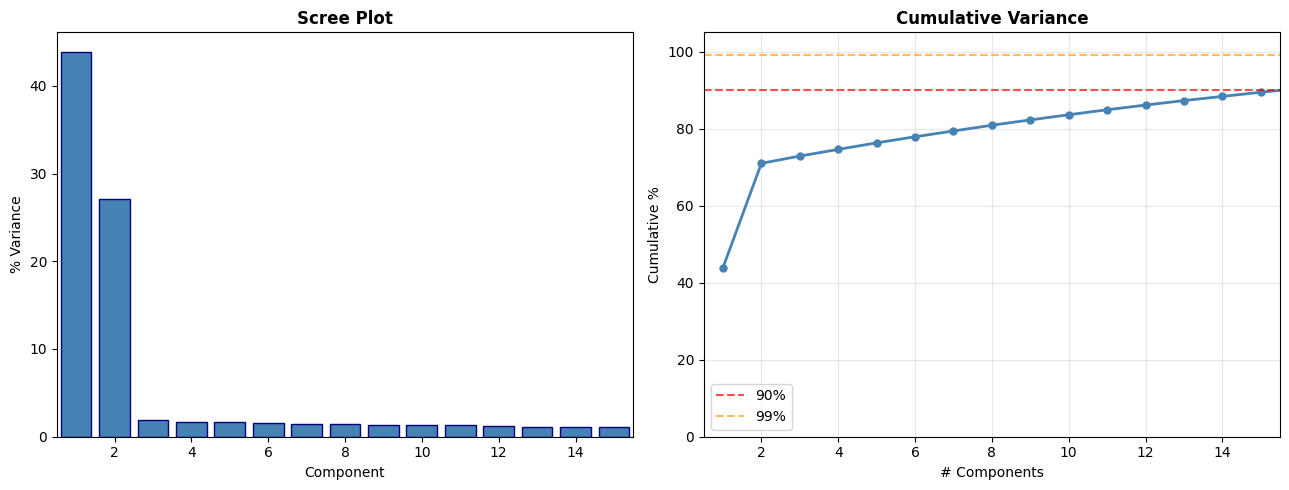


90%: 16 components, 99%: 28 components (of 30)


In [7]:
np.random.seed(42)
m, n = 50, 30
p1 = np.outer(np.sin(np.linspace(0, 2*np.pi, m)), np.ones(n))
p2 = np.outer(np.ones(m), np.cos(np.linspace(0, np.pi, n)))
p3 = np.outer(np.linspace(-1, 1, m), np.linspace(1, -1, n))
X = 5*p1 + 3*p2 + 1*p3 + 0.5*np.random.randn(m, n)

sv = np.linalg.svd(X, compute_uv=False)
pct = 100 * sv / sv.sum()
cum = np.cumsum(pct)

print(f"Top 10 components:")
print(f"{'#':>3} {'sigma':>10} {'%Var':>8} {'Cum%':>8}")
for i in range(10):
    print(f"{i+1:>3} {sv[i]:>10.3f} {pct[i]:>7.1f}% {cum[i]:>7.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1, len(sv)+1), pct, color='steelblue', edgecolor='navy')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('% Variance')
axes[0].set_title('Scree Plot', fontweight='bold'); axes[0].set_xlim(0.5, 15.5)

axes[1].plot(range(1, len(sv)+1), cum, 'o-', color='steelblue', lw=2, ms=5)
axes[1].axhline(90, color='red', ls='--', alpha=0.7, label='90%')
axes[1].axhline(99, color='orange', ls='--', alpha=0.7, label='99%')
axes[1].set_xlabel('# Components'); axes[1].set_ylabel('Cumulative %')
axes[1].set_title('Cumulative Variance', fontweight='bold')
axes[1].set_xlim(0.5, 15.5); axes[1].set_ylim(0, 105)
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

n90 = np.searchsorted(cum, 90)+1; n99 = np.searchsorted(cum, 99)+1
print(f"\n90%: {n90} components, 99%: {n99} components (of {len(sv)})")

**The Condition Number**

I’ve hinted several times in this book that the condition number of a matrix is used to
indicate the numerical stability of a matrix. Now that you know about singular values,
you can better appreciate how to compute and interpret the condition number.

The condition number is often used in statistics and machine learning to evaluate the
stability of a matrix when computing its inverse and when using it to solve systems
of equations (e.g., least squares). Of course, a noninvertible matrix has a condition
number of NaN because σ/0 =‽.
But a numerically full-rank matrix with a large condition number can still be unsta‐
ble. Though theoretically invertible, in practice the matrix inverse may be unreliable.
Such matrices are called ill-conditioned. You might have seen that term in warning
messages in Python, sometimes accompanied by phrases like “result is not guaranteed
to be accurate.”

In [8]:
A_good = np.array([[2, 1], [1, 3]])
A_bad = np.array([[1.0, 1.0], [1.0, 1.0 + 1e-10]])
A_sing = np.array([[1, 2], [2, 4]])

for nm, Ac in [("Well-conditioned", A_good), ("Ill-conditioned", A_bad), ("Singular", A_sing)]:
    sc = np.linalg.svd(Ac, compute_uv=False)
    k = sc[0]/sc[-1] if sc[-1] > 0 else np.inf
    print(f"{nm}: sigma = {sc}, kappa = {k:.2e}")

print("\n--- Instability demo ---")
b = np.array([3.0, 3.0 + 1e-10])
x1 = np.linalg.solve(A_bad, b)
x2 = np.linalg.solve(A_bad, b + np.array([1e-11, -1e-11]))
print(f"x = {x1}")
print(f"x (b perturbed by 1e-11) = {x2}")
print(f"Change in x: {np.linalg.norm(x1-x2):.2e} (huge from tiny perturbation!)")

Well-conditioned: sigma = [3.618 1.382], kappa = 2.62e+00
Ill-conditioned: sigma = [2. 0.], kappa = 4.00e+10
Singular: sigma = [5. 0.], kappa = 2.52e+16

--- Instability demo ---
x = [2. 1.]
x (b perturbed by 1e-11) = [2.2 0.8]
Change in x: 2.83e-01 (huge from tiny perturbation!)


The Pseudoinverse -- Simple Yet Powerful

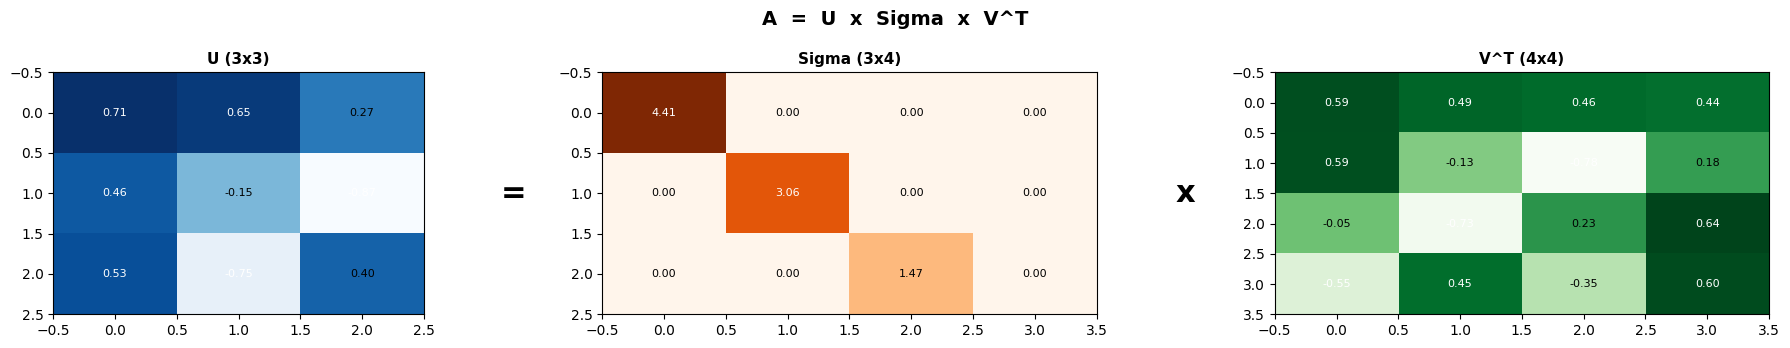

Sigma = [4.4097 3.0646 1.4707]
Reconstructs? True


In [9]:
A_v = np.array([[3,1,0,2],[1,2,1,0],[0,1,3,1]])
U_v, s_v, Vt_v = np.linalg.svd(A_v)
S_v = np.zeros(A_v.shape); np.fill_diagonal(S_v, s_v)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5),
    gridspec_kw={'width_ratios': [3, 0.5, 4, 0.5, 4]})
items = [(U_v, f'U ({U_v.shape[0]}x{U_v.shape[1]})', 'Blues'),
         (None, '=', None),
         (S_v, f'Sigma ({S_v.shape[0]}x{S_v.shape[1]})', 'Oranges'),
         (None, 'x', None),
         (Vt_v, f'V^T ({Vt_v.shape[0]}x{Vt_v.shape[1]})', 'Greens')]
for ax, (mat, title, cmap) in zip(axes, items):
    if mat is None:
        ax.text(0.5, 0.5, title, ha='center', va='center', fontsize=22, fontweight='bold')
        ax.axis('off')
    else:
        ax.imshow(mat, cmap=cmap, aspect='auto')
        ax.set_title(title, fontsize=11, fontweight='bold')
        for r in range(mat.shape[0]):
            for c in range(mat.shape[1]):
                v = mat[r,c]
                clr = 'white' if abs(v) > 0.5*np.abs(mat).max() else 'black'
                ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=8, color=clr)
plt.suptitle('A  =  U  x  Sigma  x  V^T', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Sigma = {s_v.round(4)}")
print(f"Reconstructs? {np.allclose(A_v, U_v @ S_v @ Vt_v)}")